# Lab 14: Finding Outliers
## IBM Data Analytics Capstone Project
### Objective: Analyze distributions, identify and remove outliers using IQR and standard deviation methods

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the dataset
file_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"
df = pd.read_csv(file_url)

print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully!
Shape: (65437, 114)


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


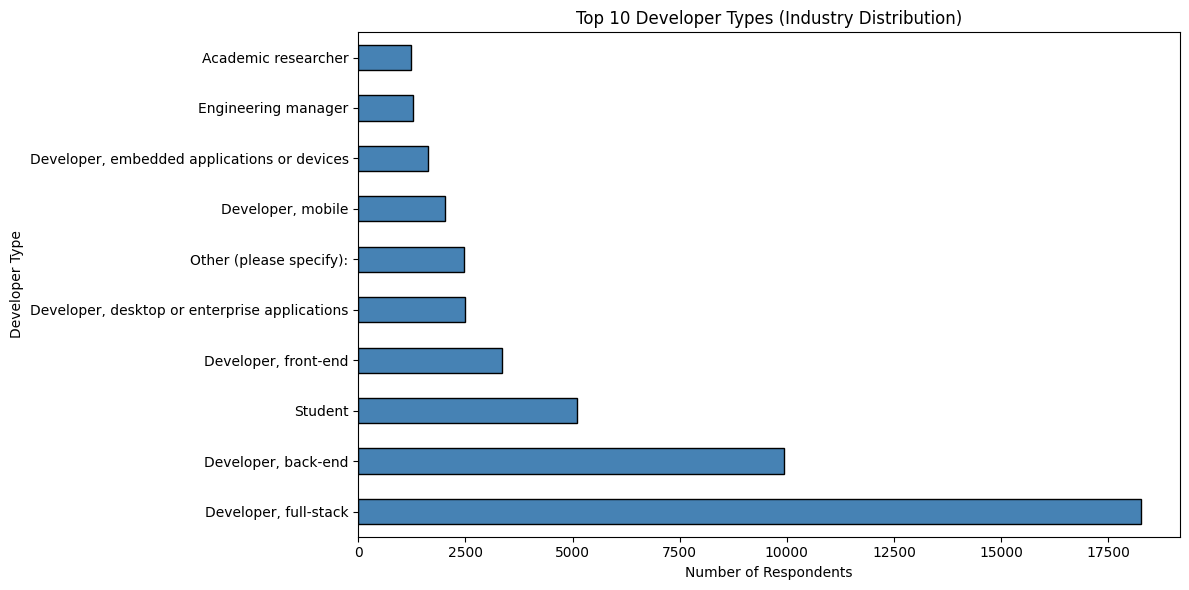

Industry distribution saved!

Top 10 Developer Types:
DevType
Developer, full-stack                            18260
Developer, back-end                               9928
Student                                           5102
Developer, front-end                              3349
Developer, desktop or enterprise applications     2493
Other (please specify):                           2458
Developer, mobile                                 2021
Developer, embedded applications or devices       1623
Engineering manager                               1275
Academic researcher                               1238
Name: count, dtype: int64


In [2]:
# Bar chart of respondents by DevType (Industry proxy)
top_devtypes = df['DevType'].dropna().str.split(';').explode()
top_devtypes = top_devtypes.value_counts().head(10)

plt.figure(figsize=(12, 6))
top_devtypes.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Top 10 Developer Types (Industry Distribution)')
plt.xlabel('Number of Respondents')
plt.ylabel('Developer Type')
plt.tight_layout()
plt.savefig('industry_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Industry distribution saved!")
print("\nTop 10 Developer Types:")
print(top_devtypes)

In [3]:
# Basic statistics for ConvertedCompYearly
comp = df['ConvertedCompYearly'].dropna()

mean_comp = comp.mean()
median_comp = comp.median()
std_comp = comp.std()

print("ConvertedCompYearly Statistics:")
print(f"  Mean:   ${mean_comp:,.2f}")
print(f"  Median: ${median_comp:,.2f}")
print(f"  Std Dev: ${std_comp:,.2f}")

# Identify values exceeding 3 standard deviations
threshold = mean_comp + 3 * std_comp
high_outliers = df[df['ConvertedCompYearly'] > threshold]

print(f"\n3 Std Dev Threshold: ${threshold:,.2f}")
print(f"Number of high compensation outliers: {len(high_outliers):,}")

ConvertedCompYearly Statistics:
  Mean:   $86,155.29
  Median: $65,000.00
  Std Dev: $186,756.97

3 Std Dev Threshold: $646,426.21
Number of high compensation outliers: 89


IQR Analysis - ConvertedCompYearly:
  Q1: $32,712.00
  Q3: $107,971.50
  IQR: $75,259.50
  Lower Bound: $-80,177.25
  Upper Bound: $220,860.75
  Number of outliers: 978


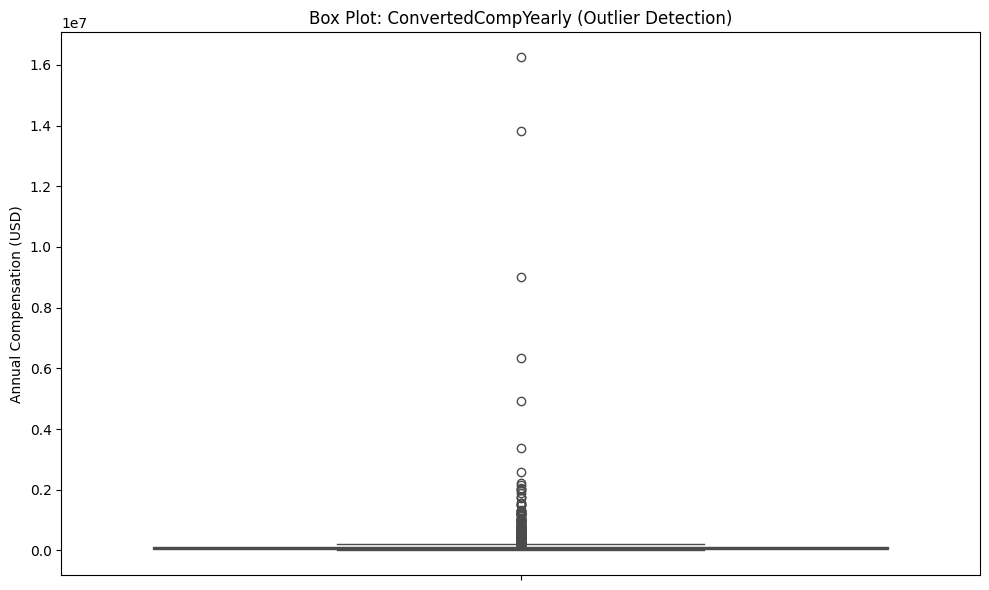

Box plot saved!


In [4]:
# Calculate IQR for ConvertedCompYearly
Q1 = comp.quantile(0.25)
Q3 = comp.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("IQR Analysis - ConvertedCompYearly:")
print(f"  Q1: ${Q1:,.2f}")
print(f"  Q3: ${Q3:,.2f}")
print(f"  IQR: ${IQR:,.2f}")
print(f"  Lower Bound: ${lower_bound:,.2f}")
print(f"  Upper Bound: ${upper_bound:,.2f}")

outliers = df[(df['ConvertedCompYearly'] < lower_bound) | 
              (df['ConvertedCompYearly'] > upper_bound)]
print(f"  Number of outliers: {len(outliers):,}")

# Box plot
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['ConvertedCompYearly'].dropna(), color='steelblue')
plt.title('Box Plot: ConvertedCompYearly (Outlier Detection)')
plt.ylabel('Annual Compensation (USD)')
plt.tight_layout()
plt.savefig('comp_boxplot_iqr.png', dpi=150, bbox_inches='tight')
plt.show()
print("Box plot saved!")

Original DataFrame shape: (65437, 114)
Clean DataFrame shape: (22457, 114)
Rows removed: 42,980


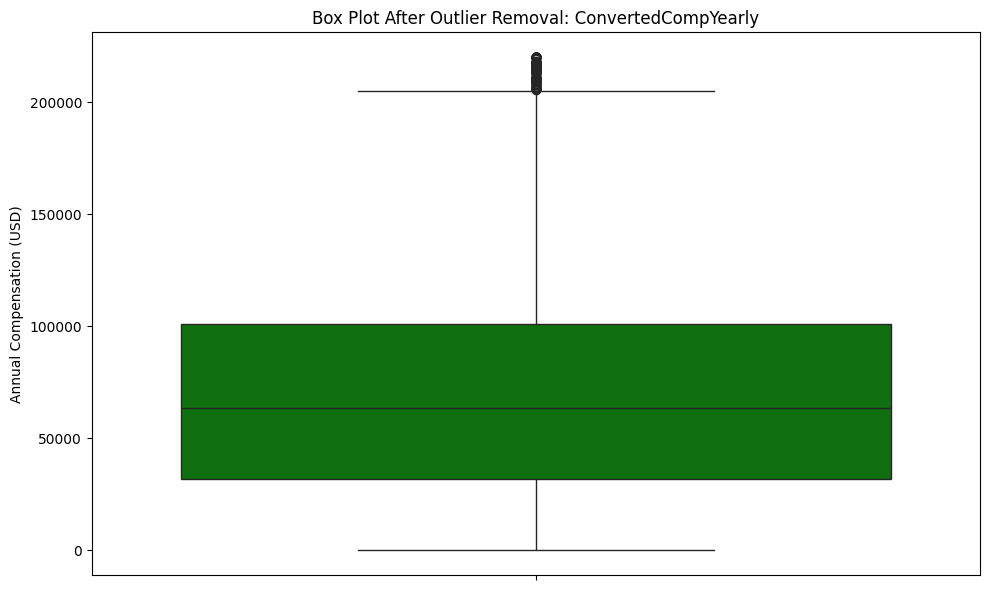

Clean box plot saved!


In [5]:
# Remove outliers from ConvertedCompYearly
df_clean = df[(df['ConvertedCompYearly'] >= lower_bound) & 
              (df['ConvertedCompYearly'] <= upper_bound)]

print("Original DataFrame shape:", df.shape)
print("Clean DataFrame shape:", df_clean.shape)
print(f"Rows removed: {df.shape[0] - df_clean.shape[0]:,}")

# Validate with box plot after removal
plt.figure(figsize=(10, 6))
sns.boxplot(y=df_clean['ConvertedCompYearly'], color='green')
plt.title('Box Plot After Outlier Removal: ConvertedCompYearly')
plt.ylabel('Annual Compensation (USD)')
plt.tight_layout()
plt.savefig('comp_boxplot_clean.png', dpi=150, bbox_inches='tight')
plt.show()
print("Clean box plot saved!")

Five-Number Summary for Age:
min    16.0
25%    29.0
50%    29.0
75%    39.0
max    70.0
Name: Age_Numeric, dtype: float64

Correlation Matrix:
                     Age_Numeric  ConvertedCompYearly  WorkExp  JobSat
Age_Numeric                1.000                0.378    0.847   0.067
ConvertedCompYearly        0.378                1.000    0.407   0.074
WorkExp                    0.847                0.407    1.000   0.092
JobSat                     0.067                0.074    0.092   1.000


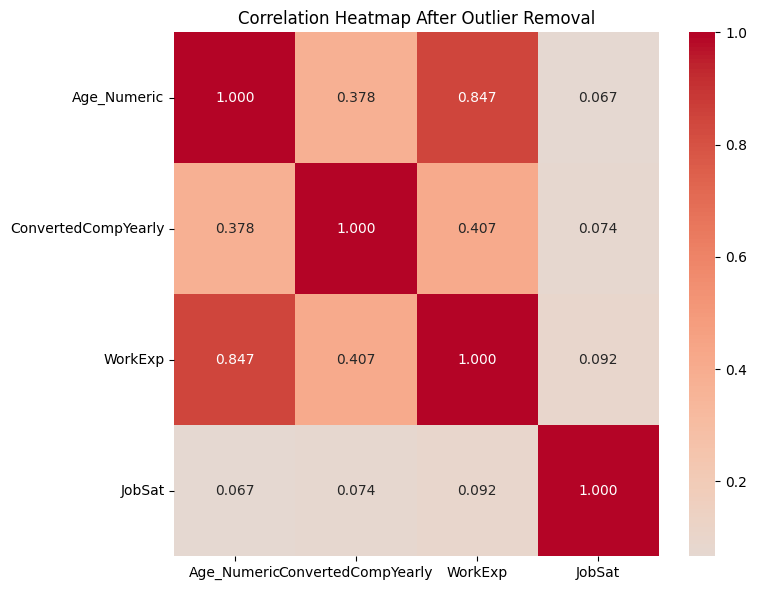

Correlation heatmap saved!


In [6]:
# Map Age to numeric values
age_mapping = {
    'Under 18 years old': 16, '18-24 years old': 21,
    '25-34 years old': 29, '35-44 years old': 39,
    '45-54 years old': 49, '55-64 years old': 59,
    '65 years or older': 70, 'Prefer not to say': None
}
df_clean = df_clean.copy()
df_clean['Age_Numeric'] = df_clean['Age'].map(age_mapping)

# Five-number summary for Age
print("Five-Number Summary for Age:")
print(df_clean['Age_Numeric'].describe()[['min','25%','50%','75%','max']])

# Correlation with other numeric columns
corr_cols = ['Age_Numeric', 'ConvertedCompYearly', 'WorkExp', 'JobSat']
corr_matrix = df_clean[corr_cols].dropna().corr()
print("\nCorrelation Matrix:")
print(corr_matrix.round(3))

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap After Outlier Removal')
plt.tight_layout()
plt.savefig('correlation_after_outlier_removal.png', dpi=150, bbox_inches='tight')
plt.show()
print("Correlation heatmap saved!")

## Summary 

### Outlier Detection Results:
- **IQR Method:** 978 outliers above $220,860
- **Rows removed:** 42,980 (mostly NaN + outliers)
- **Clean dataset:** 22,457 rows

### Key Correlations (after outlier removal):
- Age & WorkExp: 0.847 (very strong)
- Age & CompYearly: 0.378 (moderate)
- WorkExp & CompYearly: 0.407 (moderate)
- JobSat & all variables: ~0.07 (very weak)